In [1]:
%matplotlib inline
import torch
from torch import nn
from utils.train_model import train_net, sgd
from utils.get_data import get_data

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("The used device: ", device)

The used device:  cuda


In [3]:
def dropout(X, drop_prob):
    assert 0 <= drop_prob <= 1
    if drop_prob == 1:
        return torch.zeros_like(X)
    mask = (torch.rand(X.shape, device=X.device) > drop_prob).float()
    return mask * X / (1.0 - drop_prob)

In [4]:
dp1, dp2 = 0.2, 0.5
n_in = 28*28
n_out = 10
ns_hidden = [256, 256, 256, 256]
dos = [0.2, 0.2, 0.5, 0.5]
lr = 0.01
batch_size = 1024

class MyNet(nn.Module):
    def __init__(self, n_in, n_out, ns_hidden, dos, is_training):
        super(MyNet, self).__init__()
        self.n_in = n_in
        self.n_out = n_out
        self.l_in = nn.Linear(n_in, ns_hidden[0])
        self.ls_hidden = nn.ModuleList(
            [nn.Linear(ns_hidden[i-1], ns_hidden[i]) for i in range(1, len(ns_hidden))]
        )
        self.l_out = nn.Linear(ns_hidden[-1], n_out)
        self.n_hidden = len(ns_hidden)
        self.ns_hidden = ns_hidden
        self.dos = dos
        self.training = is_training
        self.relu = nn.ReLU()
        
    def forward(self, X):
        H_in = self.relu(self.l_in(X.reshape((-1, self.n_in))))
        if self.training:
            H_in = dropout(H_in, self.dos[0])
        for i in range(1, self.n_hidden):
            H = self.relu(self.ls_hidden[i-1](H_in))
            if self.training:
                H = dropout(H, self.dos[i])
            H_in = H
        out = self.l_out(H_in)
        return out
    
net = MyNet(n_in, n_out, ns_hidden, dos, True).to(device)
loss = nn.CrossEntropyLoss()
updater = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = get_data(batch_size=batch_size)

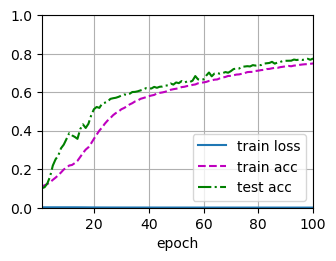

epoch 100, train loss 0.001, train acc 0.750, test acc 0.775


In [5]:
train_net(net, train_iter, test_iter, loss, net_type='Classification', updater=updater, device=device, num_epochs=100)

# Simple Implementation of Dropout

In [6]:
simple_net = nn.Sequential(nn.Flatten())
simple_net.add_module('l1', nn.Linear(n_in, ns_hidden[0]))
for i in range(1, len(ns_hidden)):
    simple_net.add_module(f'relu{i}', nn.ReLU())
    simple_net.add_module(f'dropout{i}', nn.Dropout(dos[i-1]))
    simple_net.add_module(f'l{i+1}', nn.Linear(ns_hidden[i-1], ns_hidden[i]))
simple_net.add_module('l_out', nn.Linear(ns_hidden[-1], n_out))
simple_net = simple_net.to(device)
# 使用 PyTorch 默认初始化；4 层网络若用 std=0.01 手动初始化会导致梯度过小、准确率卡在 10%
simple_updater = torch.optim.SGD(simple_net.parameters(), lr=lr)

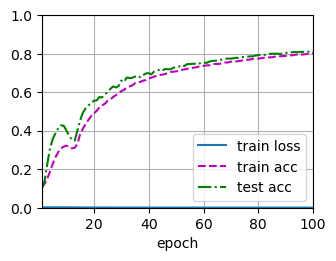

epoch 100, train loss 0.001, train acc 0.802, test acc 0.811


In [7]:
train_net(simple_net, train_iter, test_iter, loss, net_type='Classification', updater=simple_updater, device=device, num_epochs=100)